# Predicting housing prices in King County, Washington

#### Kyan Lee and Rene Vega

In this notebook, we will be predicting the price of a selling house in King County, Washington based on the previous data of sold houses in the area. We will be taking factors such as square footage, number of bedrooms, and condition grading into account. We will be using KNN regression as well as linear regression and comparing how each model performs in predicting pricing.

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import tree
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# suppress futurewarnings only
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [153]:
sns.set_theme(context='notebook', style='whitegrid')

# set default plot size
plt.rcParams['figure.figsize'] = 6,4

In [154]:
display(HTML("<style>.container { width:90% !important; }</style>"))

In [155]:
input_file = "kc_house_data.csv"
df = pd.read_csv(input_file)

## Data Preprocessing

Here, we will remove unique variables for each house as well as certain attributes that are not very helpful to our model. We will also drop the null rows as they are not too impactful to the data.

In [156]:
df.drop(['id', 'lat','long','yr_renovated', 'view', 'waterfront', 'zipcode', 'date'], axis=1, inplace=True)
df=df.dropna()

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21597 non-null  float64
 1   bedrooms       21597 non-null  int64  
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  int64  
 4   sqft_lot       21597 non-null  int64  
 5   floors         21597 non-null  float64
 6   condition      21597 non-null  int64  
 7   grade          21597 non-null  int64  
 8   sqft_above     21597 non-null  int64  
 9   sqft_basement  21597 non-null  object 
 10  yr_built       21597 non-null  int64  
 11  sqft_living15  21597 non-null  int64  
 12  sqft_lot15     21597 non-null  int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 2.1+ MB


# Data Exploration

Now, let's see what we are working with. It is important to see what trends we can find in the data so that we have an idea of what we are trying to predict.

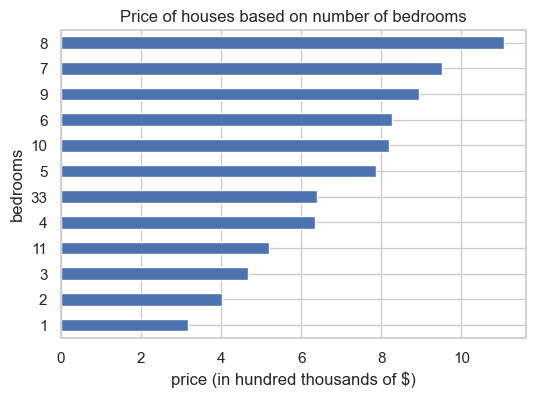

In [158]:
(df.groupby(df['bedrooms'])['price'].mean()/100000).sort_values().plot.barh()
plt.title("Price of houses based on number of bedrooms")
plt.xlabel("price (in hundred thousands of $)");

Here we can see that on average, houses with 7-9 bedrooms are selling for a higher price than other houses. This is taking into account that the general number of houses with more than 3 bedrooms can be a lot smaller than those with less.

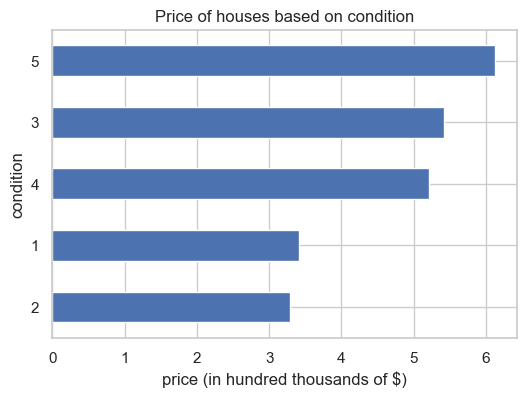

In [159]:
(df.groupby(df['condition'])['price'].mean()/100000).sort_values().plot.barh()
plt.title("Price of houses based on condition")
plt.xlabel("price (in hundred thousands of $)");

As expected, we can also see that an increase in condition grading will also lead to a higher selling price.

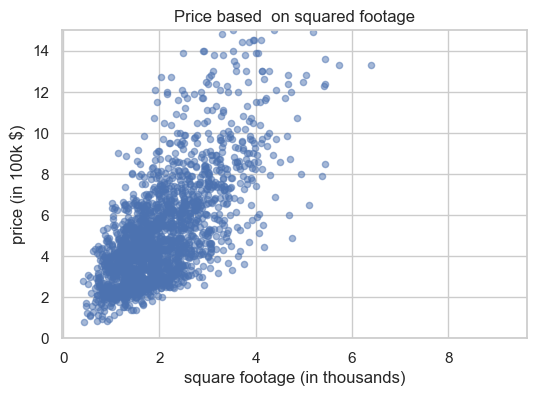

In [160]:
df['sqft_living_scaled'] = df['sqft_living'] / 1000
df['price_scaled'] = df['price'] / 100000

df.sample(2000).plot.scatter(x='sqft_living_scaled', y='price_scaled', alpha=0.5)
plt.title('Price based  on squared footage')
plt.xlabel('square footage (in thousands)')
plt.ylabel('price (in 100k $)')
plt.ylim(0,15);


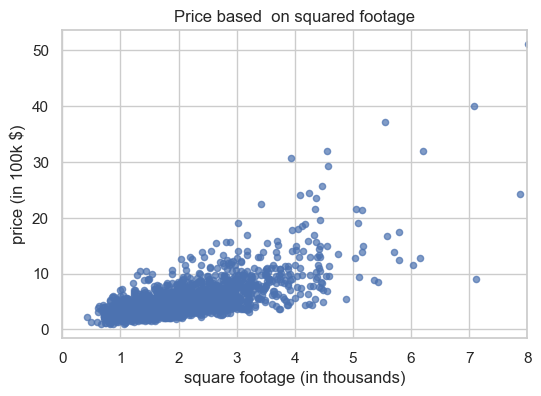

In [161]:
df.sample(2000).plot.scatter(x='sqft_living_scaled', y='price_scaled', alpha=0.7)
plt.title('Price based  on squared footage')
plt.xlabel('square footage (in thousands)')
plt.ylabel('price (in 100k $)')
plt.xlim(0,8);

We can see the general increase in price as these factors increase, so what we want to look for in our model is this same trend of increasing bedroom number or square footage will mean increasing price. This makes a lot of logical sense, so we should not run into too many problems with our predictions. In general, it is easy for humans to approximate the direction in which price is moving, so let's see how well the computer does.

# Machine Learning

Starting off with a normal test/train split, we will set the predictors we will be using as well as some baseline calculations to get an idea of what we are looking for.

In [162]:
predictors = ['sqft_living','grade', 'bathrooms', 'bedrooms', 'condition', 'sqft_lot', 'sqft_above']
target = 'price'
X = df[predictors].values
y = df[target].values

# split the data into training and testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state = 42)

# compute the most common price in the training set
most_common_price = pd.Series(y_train).value_counts().index[0]
print("Most common price in the training set:", most_common_price)

Most common price in the training set: 350000.0


Now we can scale the data and run in through a grid search in order to pick out the best parameters for our knn.

In [163]:
# scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# set up the grid search parameters
param_grid = {
    'n_neighbors': range(1, 22, 2),
    'p': [1, 2]
}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=10)
grid_search.fit(X_train, y_train)
print("Best parameters from grid search:", grid_search.best_params_)

Best parameters from grid search: {'n_neighbors': 19, 'p': 1}


This will be the evaluation of our first model, the KNN regressor.

In [ ]:
# create regressor object
regr = KNeighborsRegressor(n_neighbors=19, p=1)
regr.fit(X_train, y_train)


cv_rmse = -cross_val_score(regr, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5).mean()
cv_mae = -cross_val_score(regr, X_train, y_train, scoring='neg_mean_absolute_error', cv=5).mean()
print(f'CV RMSE: {cv_rmse:5.1f}, CV MAE: {cv_mae:5.1f}')

Predicted prices: [214792.10526316 298660.21052632 363986.05263158 346739.47368421
 405651.05263158]
Actual prices: [132500. 415000. 494000. 355000. 606000.]


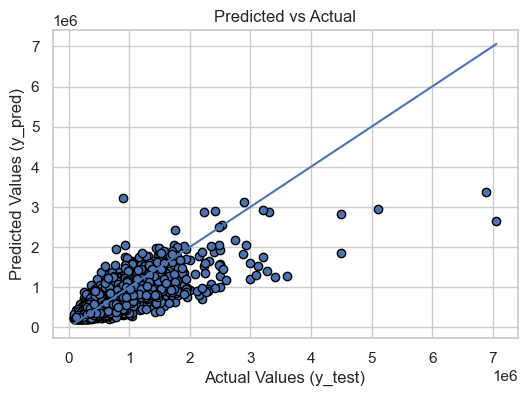

In [ ]:

# predicted prices based on the selected predictor variables
y_pred = regr.predict(X_test)

# display the first 10 predicted and actual prices
print("Predicted prices:", y_pred[:5])
print("Actual prices:", y_test[:5])

plt.scatter(y_test, y_pred, edgecolors='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])  # perfect prediction line

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Predicted vs Actual");


In [165]:
# compute the baseline rmse value
mean_target = y_train.mean()
mse_baseline = ((mean_target - y_train) ** 2).mean()
rmse_baseline = np.sqrt(mse_baseline)
print(f"Baseline RMSE: {rmse_baseline:.3f}")

# compute the baseline mae value
median_target = y_train.mean()
mae_baseline = (np.abs(median_target - y_train)).mean()
print(f"Baseline MAE: {mae_baseline:.3f}")

# compute the mean squared error
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.3f}")

# compute the root mean squared error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.3f}")

# compute the mean absolute error
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error: {mae:.3f}")


Baseline RMSE: 368717.154
Baseline MAE: 235842.040
Mean Squared Error: 51934167464.935
Root Mean Squared Error: 227890.692
Mean Absolute Error: 141252.989


We can see that the RMSE and MAE are marginally better than the baseline, so the KNN regressor definitely made some improvements from the baseline. Now we will go to a linear regression model to see the differences in each ML approach.

In [166]:
linRegr = LinearRegression()

cv_rmse = -cross_val_score(linRegr, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5).mean()
cv_mae = -cross_val_score(linRegr, X_train, y_train, scoring='neg_mean_absolute_error', cv=5).mean()
print(f'CV RMSE: {cv_rmse:5.1f}, CV MAE: {cv_mae:5.1f}')

CV RMSE: 243234.1, CV MAE: 159100.9


Predicted prices: [118521.16423552 333914.24456074 364797.24410084 346793.41864669
 376106.5291282 ]
Actual prices: [132500. 415000. 494000. 355000. 606000.]


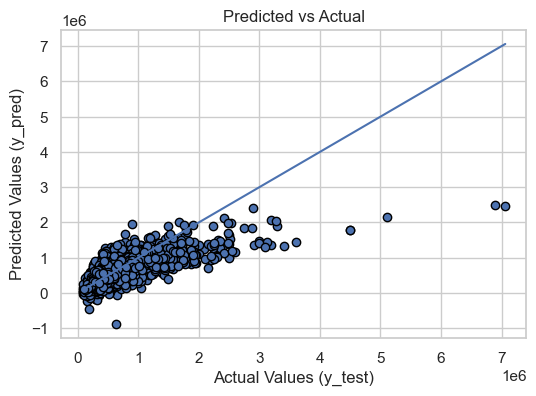

In [167]:
linRegr.fit(X_train, y_train); 
y_pred = linRegr.predict(X_test)

print("Predicted prices:", y_pred[:5])
print("Actual prices:", y_test[:5])

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, edgecolors='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])  # perfect prediction line

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Predicted vs Actual");

This looks much closer in groupings than the KNN regressor. There is a lot less variance within the model though there seems to be a bit of a more inaccurate prediction as the values get higher in actuality.

In [168]:
# compute the baseline rmse value
mean_target = y_train.mean()
mse_baseline = ((mean_target - y_train) ** 2).mean()
rmse_baseline = np.sqrt(mse_baseline)
print(f"Baseline RMSE: {rmse_baseline:.3f}")

# compute the baseline mae value
median_target = y_train.mean()
mae_baseline = (np.abs(median_target - y_train)).mean()
print(f"Baseline MAE: {mae_baseline:.3f}")

# compute the mean squared error
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.3f}")

# compute the root mean squared error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.3f}")

# compute the mean absolute error
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error: {mae:.3f}")

Baseline RMSE: 368717.154
Baseline MAE: 235842.040
Mean Squared Error: 59916457758.499
Root Mean Squared Error: 244778.385
Mean Absolute Error: 156874.298


Though the calculations look a bit worse on paper, they are not that much different than they were with the KNN regressor.

# Conclusion

In our opinion, it looks like the linear regression model is a lot better than the knn regressor model. We can see from comparing the two graphs that overall variance is lower in our linear regression model. The predictions are much closer to the line than that of the previous graph.